In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import START, END
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
import os
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
os.environ["GROQ_API_KEY"]= os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]= os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGSMITH_TRACING"]="true"
os.environ["LANGSMITH_PROJECT"]="Test" # if we don't give project name in langgraph it come as default project

# above is required for langsmith monitoring/debugging

In [3]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.15'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001BC26E9E950>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001BC26F572D0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [4]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [5]:
# graph with tool call

@tool
def add(a:float, b:float):
    """Add Two Numbers"""
    return a+b

tool_node=ToolNode([add])
tools=[add]

llm_with_tool=llm.bind_tools([add])



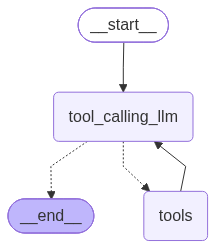

In [6]:
## STATGRAPH
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image,display

##  NODE DEFINATION
def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## GRAPH
builder=StateGraph(State)
builder.add_node("tool_calling_llm",call_llm_model)
builder.add_node("tools",ToolNode(tools))

## EDGES
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ## decide if need to call tool or directly go to end
    tools_condition
)
# builder.add_edge("tools",END) # this directly give the tools output because after tool call it ends 
builder.add_edge("tools","tool_calling_llm") # after tools call this goes to the tool calling llm again,now multiple tool calls can be done if needed


## COMPILE GRAPH
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))



In [7]:
response=graph.invoke({"messages":"What is Machine learning?"})
response
# we can see complete flow of this execution in langsmith dashboard

{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='fbeec661-deee-402d-b8ef-974ee4a21978'),
  AIMessage(content='**Machine learning (ML)** is a subfield of artificial intelligence that focuses on building algorithms and models that can learn patterns and make decisions from data, without being explicitly programmed for each specific task.\n\n### Core Idea\n- **Learning from data**: Instead of hard‑coding rules, ML models learn statistical relationships by observing examples.\n- **Generalization**: After training, the model should perform well on new, unseen data.\n\n### Key Types of ML\n\n| Type | Description | Typical Use‑Cases |\n|------|-------------|------------------|\n| **Supervised learning** | Learn a mapping from inputs to outputs using labeled data. | Image classification, spam detection, regression tasks. |\n| **Unsupervised learning** | Discover structure in unlabeled data. | Clustering customers, anomaly detection

In [8]:
response=graph.invoke({"messages":"What is 20 plus 80"})
response
# we can see complete flow of this execution in langsmith dashboard
# currently in edges tool goes to end so its giving tool message as final output not ai message because when we were adding edges we write tool->end

{'messages': [HumanMessage(content='What is 20 plus 80', additional_kwargs={}, response_metadata={}, id='f3e14d2a-b53c-4c9c-b132-3e3fe3cb6494'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks "What is 20 plus 80". We need to add numbers. Use function.', 'tool_calls': [{'id': 'fc_60a186bf-bbf8-4ba4-b8f6-d4332bd1a329', 'function': {'arguments': '{"a":20,"b":80}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 127, 'total_tokens': 174, 'completion_time': 0.048605108, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.007254528, 'prompt_tokens_details': None, 'queue_time': 0.239781791, 'total_time': 0.055859636}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8084062adb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0293c-3f24-73f1-9fb0-249239624787-0', tool_calls=[{'name': 'add', 'arg

In [9]:
response=graph.invoke({"messages":"What is 33 plus 67"})
response
# we can see complete flow of this execution in langsmith dashboard
# Now in edges tool goes to tool calling llm so final output would be ai message because when we were adding edges we write tool->tool_calling_llm

{'messages': [HumanMessage(content='What is 33 plus 67', additional_kwargs={}, response_metadata={}, id='0b0d4ec5-7c98-4352-8fda-d73db7900812'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "What is 33 plus 67". Simple addition. Should call function add.', 'tool_calls': [{'id': 'fc_d8393ade-f8c8-44f2-ba25-35625c521d9b', 'function': {'arguments': '{"a":33,"b":67}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 127, 'total_tokens': 174, 'completion_time': 0.049723529, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.007176715, 'prompt_tokens_details': None, 'queue_time': 0.192432047, 'total_time': 0.056900244}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_587d0d67cc', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0293c-423c-7c30-a61e-eec4a944e4d1-0', tool_calls=[{'name': 'add'